In [19]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal, spearmanr
import metricas_plots

In [20]:
importlib.reload(metricas_plots)
from metricas_plots import PlotsMetricas, T, F
p = PlotsMetricas()

### Ler dados

In [21]:
dados = pd.read_csv("dados/ariel_limpo_log10.csv.gz", compression="gzip")

In [22]:
# Definir feature, target e gerar splits
col_x = F.azmass.value
larguras = p.targets[:4]
train, test = train_test_split(dados[[col_x] + larguras], test_size=0.3, random_state=4321)

## Calcular Estatísticas por Bin para o treinamento

In [23]:
# Faz o agrupamento dos dados
nbins = 150
train[f'{col_x}_mean'] = pd.qcut(train[col_x], nbins)
test[f'{col_x}_mean'] = pd.qcut(test[col_x], nbins)

def gera_stats(dados_split, col_x):
    stats_list = []
    for bin_name, group in dados_split.groupby(f'{col_x}_mean'):
        if len(group) < 5:  # Pular bins com poucos dados
            continue
        
        # Ponto central de cada bin
        col_center = group[col_x].mean()
        
        # Calcular média e desvio padrão
        dados_larguras = group[larguras].values
        means = dados_larguras.mean(axis=0)
        stds = dados_larguras.std(axis=0)
        
        # Calcular matriz de covariância 4x4
        cov_matrix = np.cov(dados_larguras, rowvar=False)
        
        # Montar dicionário com todas as estatísticas
        stat_dict = {col_x: col_center}    
        for i, largura in enumerate(larguras):
            stat_dict[f'{largura}_mean'] = means[i]
            stat_dict[f'{largura}_std'] = stds[i]
        for l1, l2 in p.cov_pairs: # covariâncias
            i1 = larguras.index(l1)
            i2 = larguras.index(l2)
            stat_dict[f'cov_{l1}_{l2}'] = cov_matrix[i1, i2]
        
        stats_list.append(stat_dict)
    return stats_list

train_por_bin = pd.DataFrame(gera_stats(train, col_x))
test_por_bin = pd.DataFrame(gera_stats(test, col_x))
test_por_bin.tail()

,aZmass,nii_6584_ew_mean,nii_6584_ew_std,halpha_ew_mean,halpha_ew_std,oiii_5007_ew_mean,oiii_5007_ew_std,hbeta_ew_mean,hbeta_ew_std,cov_nii_6584_ew_halpha_ew,cov_nii_6584_ew_oiii_5007_ew,cov_nii_6584_ew_hbeta_ew,cov_halpha_ew_oiii_5007_ew,cov_halpha_ew_hbeta_ew,cov_oiii_5007_ew_hbeta_ew
145,0.282974,0.344682,0.350224,0.455673,0.508622,-0.015738,0.487930,-0.099868,0.454320,0.150835,0.111511,0.120731,0.173665,0.217945,0.155885
146,0.315994,0.314616,0.376845,0.437630,0.530117,-0.086308,0.419387,-0.104529,0.456725,0.172449,0.101043,0.130364,0.150372,0.226525,0.124544
147,0.354121,0.344093,0.389860,0.517828,0.600254,-0.017556,0.498583,-0.063857,0.535786,0.196509,0.117572,0.159281,0.222969,0.307903,0.193362
148,0.418853,0.469870,0.435308,0.707359,0.690711,0.169733,0.587401,0.115667,0.615605,0.267130,0.186098,0.220120,0.338723,0.409662,0.302219
149,0.517795,0.614712,0.378010,1.097219,0.562636,0.405772,0.524070,0.479059,0.485172,0.169267,0.085822,0.141126,0.218101,0.263910,0.196200


## Treinar Operons para Média, Desvio Padrão e Covariâncias

In [24]:
# Dicionário para armazenar os modelos
modelos = {}

# 1. Treinar modelos para MÉDIA (4 modelos)
def treinar_medias(hyper, X_train_bins):
    print("\n[1/3] TREINANDO MODELOS DE MÉDIA")
    print("-" * 80)
    for largura in larguras:
        print(f"Treinando MÉDIA para {largura}...")
        y = train_por_bin[f'{largura}_mean'].values.astype(np.float64)
        modelo = p.treinar_operon(hyper, X_train_bins, y)
        modelos[f'{largura}_mean'] = modelo

# 2. Treinar modelos para DESVIO PADRÃO (4 modelos)
def treinar_stds(hyper, X_train_bins):
    print("\n[2/3] TREINANDO MODELOS DE DESVIO PADRÃO")
    print("-" * 80)
    for largura in larguras:
        print(f"Treinando DESVIO PADRÃO para {largura}...")
        y = train_por_bin[f'{largura}_std'].values.astype(np.float64)
        modelo = p.treinar_operon(hyper, X_train_bins, y)
        modelos[f'{largura}_std'] = modelo

# 3. Treinar modelos para COVARIÂNCIAS (6 modelos)
def treinar_covs(hyper, X_train_bins):
    print("\n[3/3] TREINANDO MODELOS DE COVARIÂNCIA")
    print("-" * 80)
    for l1, l2 in p.cov_pairs:
        print(f"Treinando COVARIÂNCIA para {l1} x {l2}...")
        y = train_por_bin[f'cov_{l1}_{l2}'].values.astype(np.float64)
        modelo = p.treinar_operon(hyper, X_train_bins, y)
        modelos[f'cov_{l1}_{l2}'] = modelo

In [25]:
# Selecionar feature para o treinamento
X_train_bins = train_por_bin[col_x].values.reshape(-1, 1).astype(np.float64)

# Configuração do Operon
hyper = {
    'random_state': 4321,
    'population_size': 1000,
    'allowed_symbols': "add,sub,mul,aq,constant,variable,pow,exp,tanh",
    "max_length": 25,
    "max_depth": 25,
    'model_selection_criterion': 'bayesian_information_criterion',
    'objectives': ['r2', 'length'],
    'n_threads': 12,
}

treinar_medias(hyper, X_train_bins)
treinar_stds(hyper, X_train_bins)
treinar_covs(hyper, X_train_bins)
p.salva_equacoes_html(modelos, col_x, f"n4d_{col_x}")


[1/3] TREINANDO MODELOS DE MÉDIA
--------------------------------------------------------------------------------
Treinando MÉDIA para nii_6584_ew...
Treinando MÉDIA para halpha_ew...
Treinando MÉDIA para oiii_5007_ew...
Treinando MÉDIA para hbeta_ew...

[2/3] TREINANDO MODELOS DE DESVIO PADRÃO
--------------------------------------------------------------------------------
Treinando DESVIO PADRÃO para nii_6584_ew...
Treinando DESVIO PADRÃO para halpha_ew...
Treinando DESVIO PADRÃO para oiii_5007_ew...
Treinando DESVIO PADRÃO para hbeta_ew...

[3/3] TREINANDO MODELOS DE COVARIÂNCIA
--------------------------------------------------------------------------------
Treinando COVARIÂNCIA para nii_6584_ew x halpha_ew...
Treinando COVARIÂNCIA para nii_6584_ew x oiii_5007_ew...
Treinando COVARIÂNCIA para nii_6584_ew x hbeta_ew...
Treinando COVARIÂNCIA para halpha_ew x oiii_5007_ew...
Treinando COVARIÂNCIA para halpha_ew x hbeta_ew...
Treinando COVARIÂNCIA para oiii_5007_ew x hbeta_ew...

----

## Inspeção da qualidade dos modelos

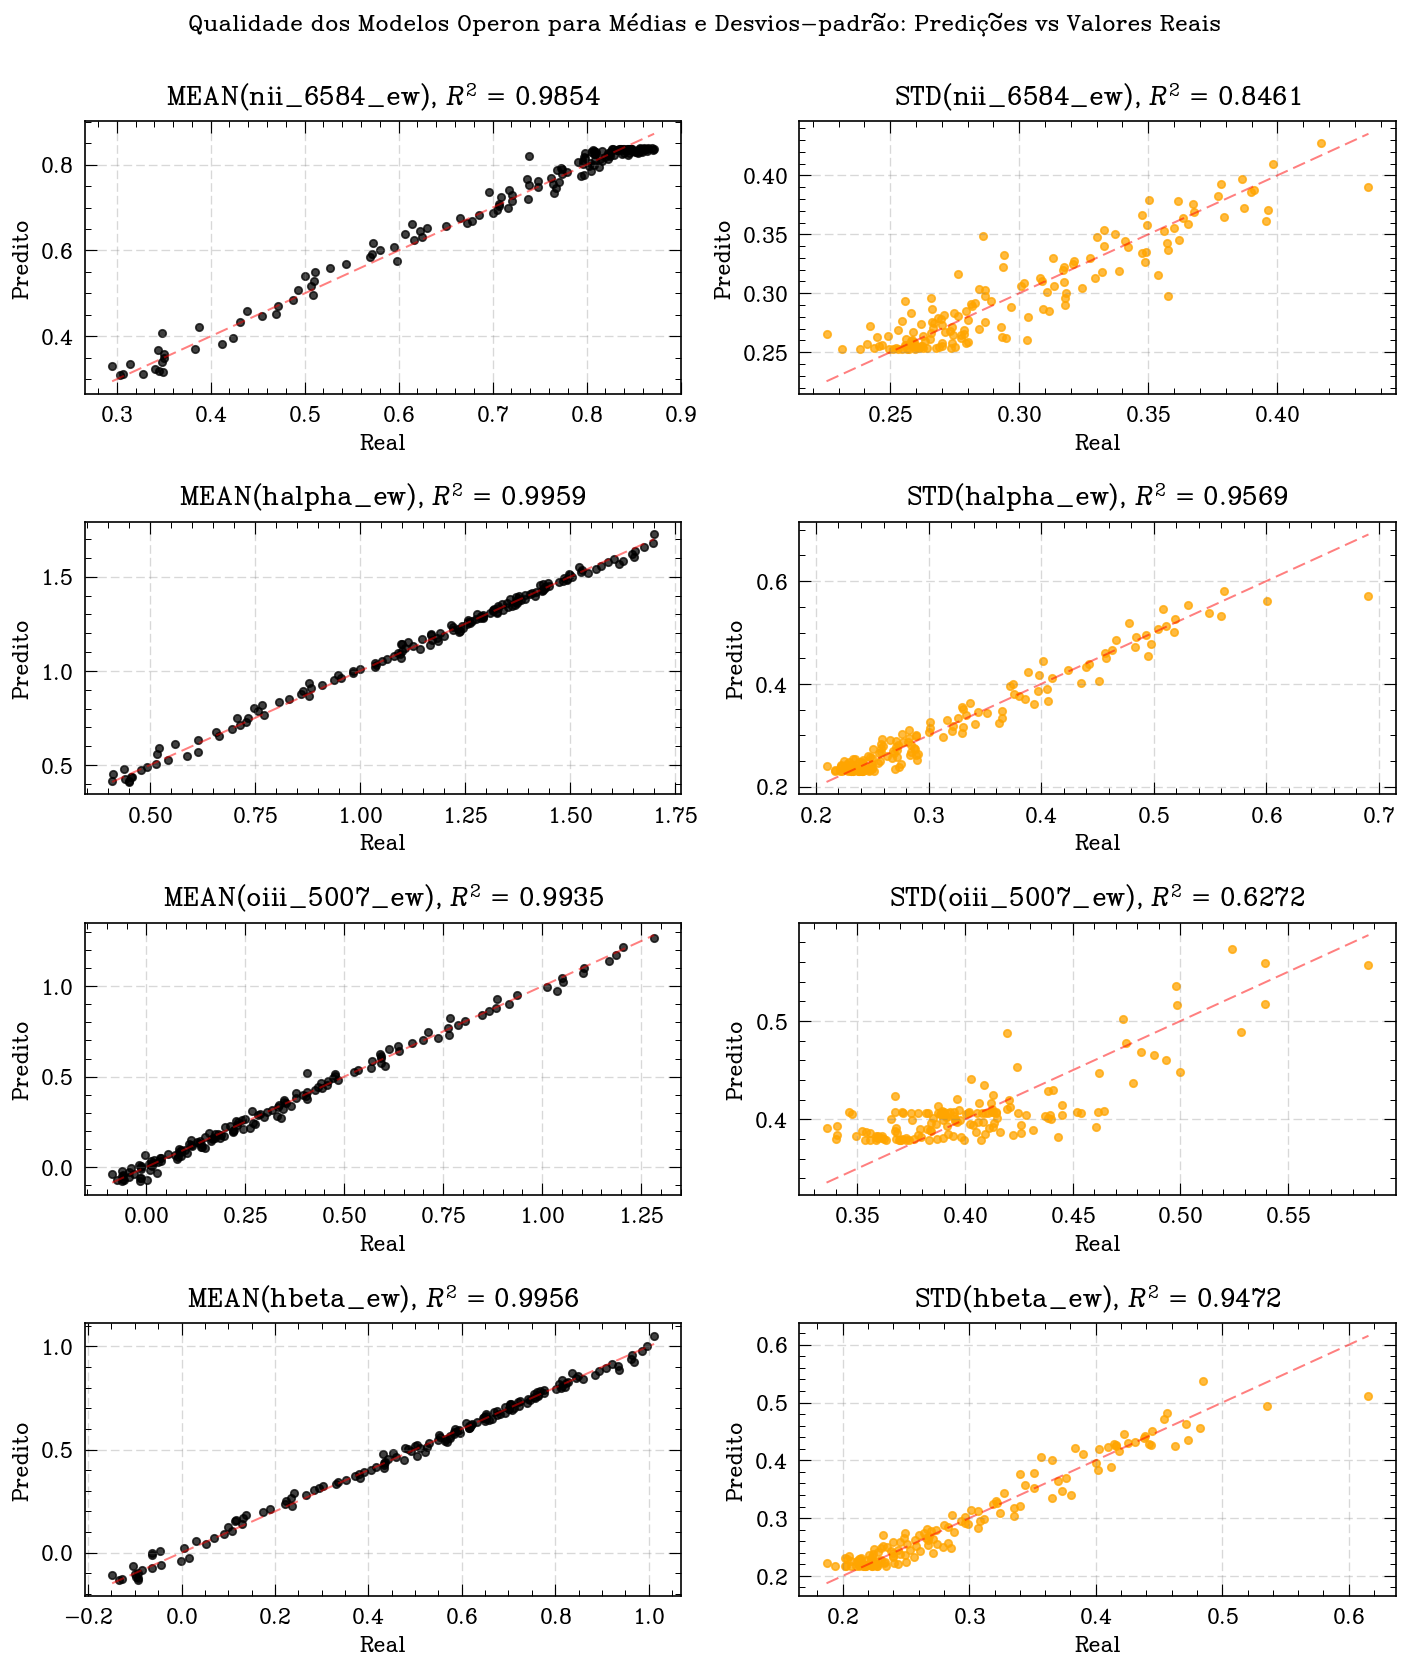

In [26]:
#p.inspecao_modelos(modelos, train_por_bin, col_x)
p.inspecao_modelos(modelos, test_por_bin, col_x)

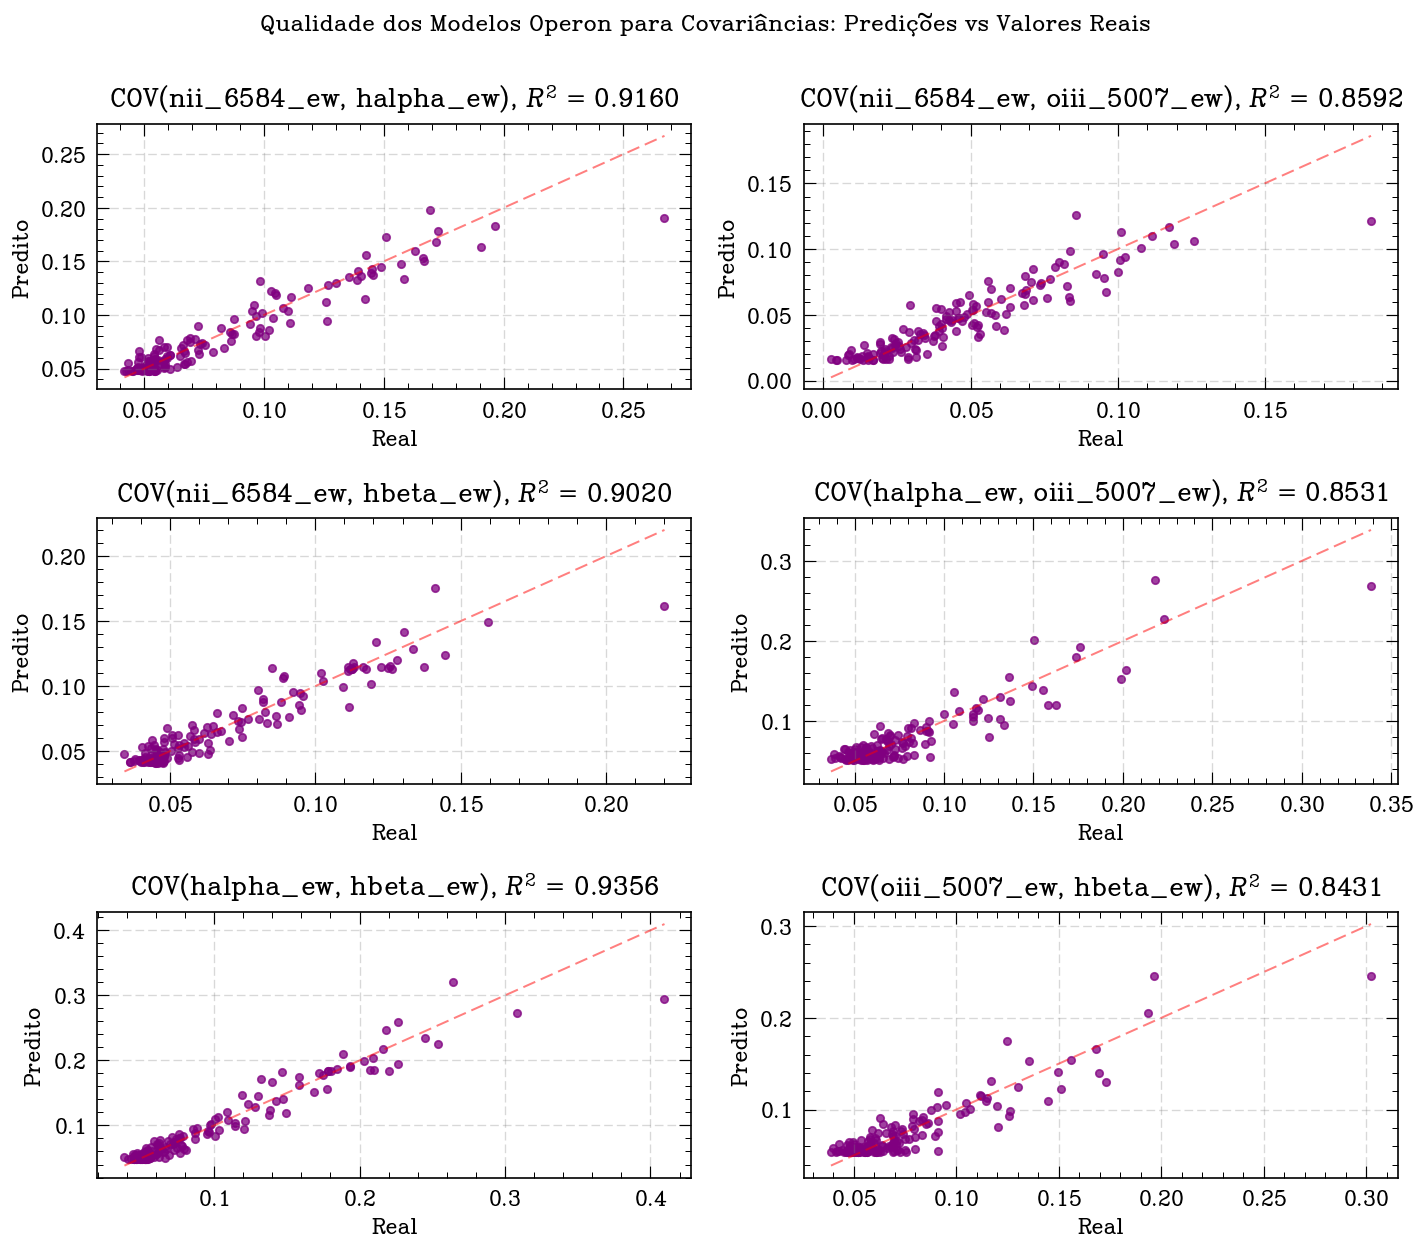

In [27]:
#p.inspecao_modelos_covs(modelos, train_por_bin, col_x)
p.inspecao_modelos_covs(modelos, test_por_bin, col_x)

In [28]:
# # Exibir alguma função treinada de interesse
# x_pred = test[[col_x]]
# y_pred = modelos[f'cov_{T.ha.value}_{T.oiii.value}'].predict(x_pred)
# plt.scatter(x_pred, y_pred, s=1, alpha=0.5)
# plt.show()

## Gerar Amostras do Conjunto de Teste com Normal Multivariada

In [29]:
def gerar_amostras(modelos, col_x):
    X_test = test[[col_x]].astype(np.float64)
    n_samples = len(X_test)
    print(f"Estimando parâmetros de {n_samples} pontos do conjunto de validação para a Normal Multivariada...\n")
    means_all = np.column_stack([modelos[f'{nome}_mean'].predict(X_test) for nome in larguras])
    stds_all = np.column_stack([np.maximum(modelos[f'{nome}_std'].predict(X_test), 1e-6) for nome in larguras])
    covs_all = {}
    for l1, l2 in p.cov_pairs:
        covs_all[(l1, l2)] = modelos[f'cov_{l1}_{l2}'].predict(X_test)
    print("Predições dos estimadores concluídas!")

    n_correcoes = 0
    amostras_multivariadas = np.zeros((n_samples, 4))
    idx_map = {nome: j for j, nome in enumerate(larguras)}
    print("\nAmostragem multivariada iniciada..\n")

    for i in range(n_samples):
        if i % 5000 == 0 and i > 0:
            print(f"  Progresso: {i}/{n_samples} ({100*i/n_samples:.1f}%)")
        
        # Montar matriz de covariância
        mean_vector = means_all[i]
        stds = stds_all[i]    
        cov_matrix = np.diag(stds**2)

        # Preencher covariâncias com validação
        for (l1_nome, l2_nome), cov_vals in covs_all.items():
            i1 = idx_map[l1_nome]
            i2 = idx_map[l2_nome]
            if np.isfinite(cov_vals[i]):
                cov_matrix[i1, i2] = cov_vals[i]
                cov_matrix[i2, i1] = cov_vals[i]

        # Remover infs e NaNs e garantir simetria
        cov_matrix = np.nan_to_num(cov_matrix, nan=0.0, posinf=0.0, neginf=0.0)
        cov_matrix = (cov_matrix + cov_matrix.T) / 2

        # Regularização robusta
        corrigiu = False
        try:
            if not np.all(np.isfinite(cov_matrix)):
                raise ValueError("Matriz ainda contém valores não-finitos")
            
            # Corrigir autovalores negativos ou muito pequenos
            min_eigenval = 1e-8
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
            if np.any(eigenvalues < min_eigenval):
                eigenvalues = np.maximum(eigenvalues, min_eigenval)
                cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
                corrigiu = True
            
            sample = multivariate_normal(mean=mean_vector, cov=cov_matrix, allow_singular=True).rvs()
            
        except Exception as e:
            # Se tudo falhar, usar matriz diagonal
            cov_matrix = np.diag(stds**2)
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
            if not np.all(np.isfinite(cov_matrix)) or np.any(eigenvalues < min_eigenval):
                print("Abortando combinação problemática, desvios diagonais inválidos!\n")
                corrigiu = False
                n_samples -= 1
                continue # esquece e passa pra próxima combinação
            sample = multivariate_normal(mean=mean_vector, cov=cov_matrix, allow_singular=False).rvs()
            corrigiu = True
            
        finally:
            if corrigiu: n_correcoes += 1

        amostras_multivariadas[i] = sample

    amostras = {
        col_x: X_test.values.flatten(),
        larguras[0]: amostras_multivariadas[:, 0],
        larguras[1]: amostras_multivariadas[:, 1],
        larguras[2]: amostras_multivariadas[:, 2],
        larguras[3]: amostras_multivariadas[:, 3]
    }

    print("\nAmostragem multivariada concluída!")
    print(f"   - Amostras: {n_samples}")
    print(f"   - Matrizes corrigidas: {n_correcoes} ({100*n_correcoes/n_samples:.1f}%)\n")
    
    # Salvando amostras em CSV
    df_amostras = pd.DataFrame(amostras)
    df_amostras.to_csv(f"results/amostras_{col_x}.csv", index=False)
    
    print("Estatísticas:\n")
    for nome in larguras:
        valores = df_amostras[nome]
        print(f"  {nome:12s}: média={valores.mean():7.3f}, std={valores.std():6.3f}, "
            f"min={valores.min():7.3f}, max={valores.max():7.3f}")

gerar_amostras(modelos, col_x)

Estimando parâmetros de 37746 pontos do conjunto de validação para a Normal Multivariada...

Predições dos estimadores concluídas!

Amostragem multivariada iniciada..

  Progresso: 5000/37746 (13.2%)
  Progresso: 10000/37746 (26.5%)
  Progresso: 15000/37746 (39.7%)
  Progresso: 20000/37746 (53.0%)
  Progresso: 25000/37746 (66.2%)
  Progresso: 30000/37746 (79.5%)
  Progresso: 35000/37746 (92.7%)

Amostragem multivariada concluída!
   - Amostras: 37746
   - Matrizes corrigidas: 2208 (5.8%)

Estatísticas:

  nii_6584_ew : média=  0.708, std= 0.341, min= -0.963, max=  2.088
  halpha_ew   : média=  1.156, std= 0.469, min= -1.668, max=  3.021
  oiii_5007_ew: média=  0.331, std= 0.529, min= -1.804, max=  3.432
  hbeta_ew    : média=  0.501, std= 0.429, min= -1.875, max=  2.285


In [30]:
# Ler amostras geradas
df_amostras = pd.read_csv(f"results/amostras_{col_x}.csv")
df_amostras = df_amostras.dropna()
df_amostras = df_amostras.reset_index(drop=True)
df_amostras.tail()

,aZmass,nii_6584_ew,halpha_ew,oiii_5007_ew,hbeta_ew
37741,-0.788271,0.715454,1.337533,0.626571,0.761044
37742,-0.764474,0.742129,1.080291,-0.042480,0.381068
37743,-1.020332,1.069514,1.730294,0.759157,1.019846
37744,-0.803633,1.121766,1.731374,0.863875,1.111957
37745,0.120283,1.550740,1.585898,1.151780,0.746474


## Calcular razões do BPT

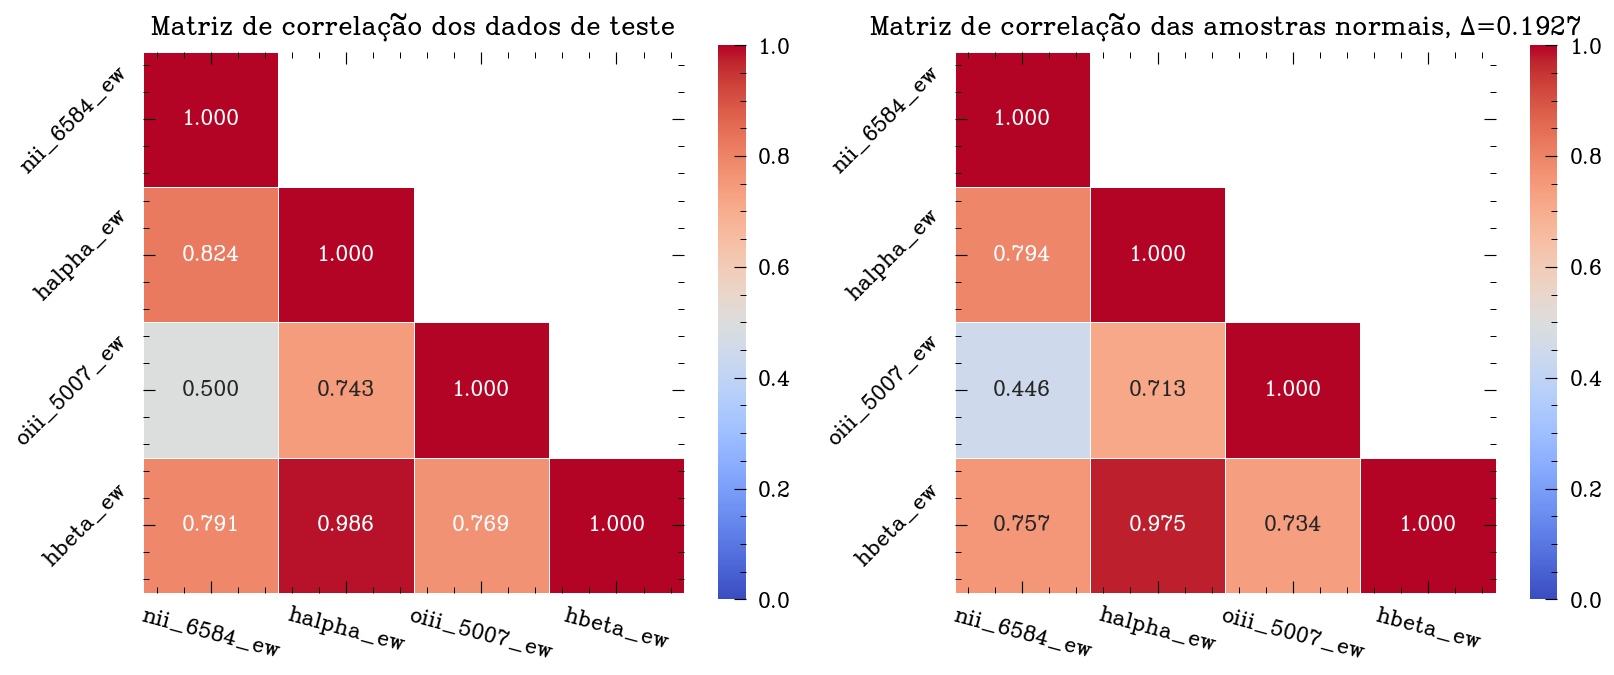

In [31]:
# Calcular razões (já estão em log10, então é só subtrair)
test[T.nii_ha.value] = test[T.nii.value].values - test[T.ha.value].values
test[T.oiii_hb.value] = test[T.oiii.value].values - test[T.hb.value].values
df_amostras[T.nii_ha.value] = df_amostras[T.nii.value] - df_amostras[T.ha.value]
df_amostras[T.oiii_hb.value] = df_amostras[T.oiii.value] - df_amostras[T.hb.value]

# Matriz de correlação das amostras geradas
corr_gerada = spearmanr(df_amostras[larguras]).correlation
df_corrger = pd.DataFrame(corr_gerada, index=larguras, columns=larguras)

# Matriz de correlação dos dados reais (test set)
test_linhas = test[larguras].values
corr_real = spearmanr(test_linhas).correlation
df_corrtest = pd.DataFrame(corr_real, index=larguras, columns=larguras)

# Diferença total absoluta
diff_df = (df_corrger - df_corrtest).abs()
diff = diff_df.values[np.triu_indices(4, k=1)].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
p.plot_corr(corr_real, axes[0], larguras, title='Matriz de correlação dos dados de teste', type='inf')
p.plot_corr(corr_gerada, axes[1], larguras, title=r'Matriz de correlação das amostras normais, $\Delta$=%.4f'%diff, type='inf')
plt.show()

### Diagramas de diagnóstico

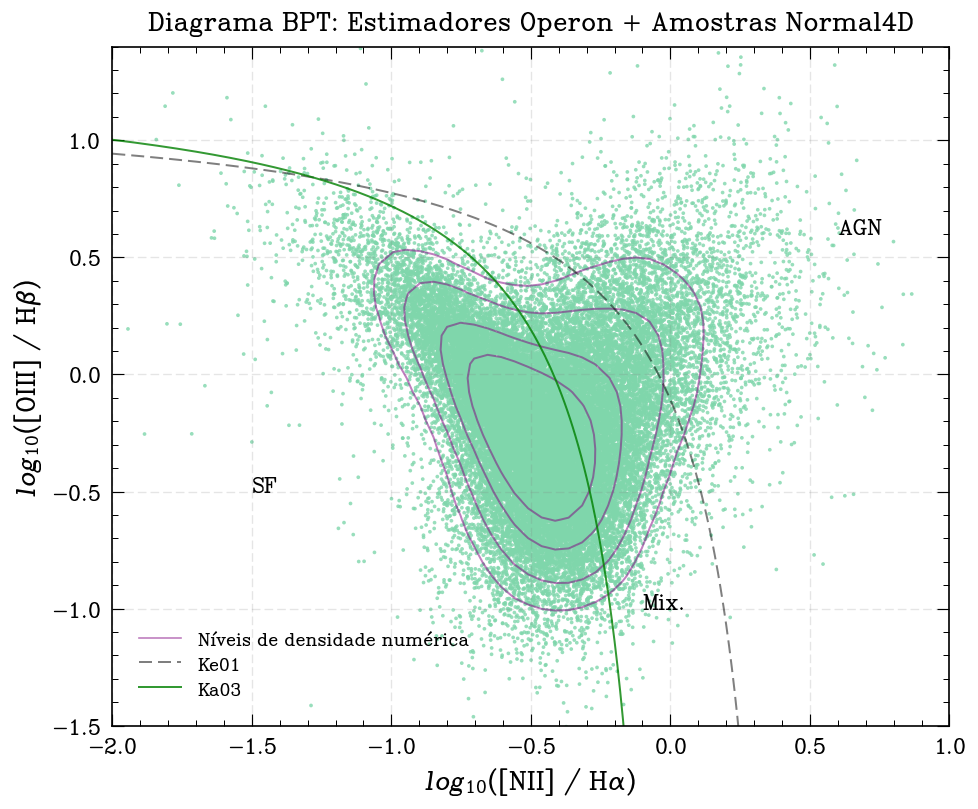

In [32]:
# Plotar com curvas de densidade
p.show_bpt(df_amostras, title="Estimadores Operon + Amostras Normal4D", densities=True)

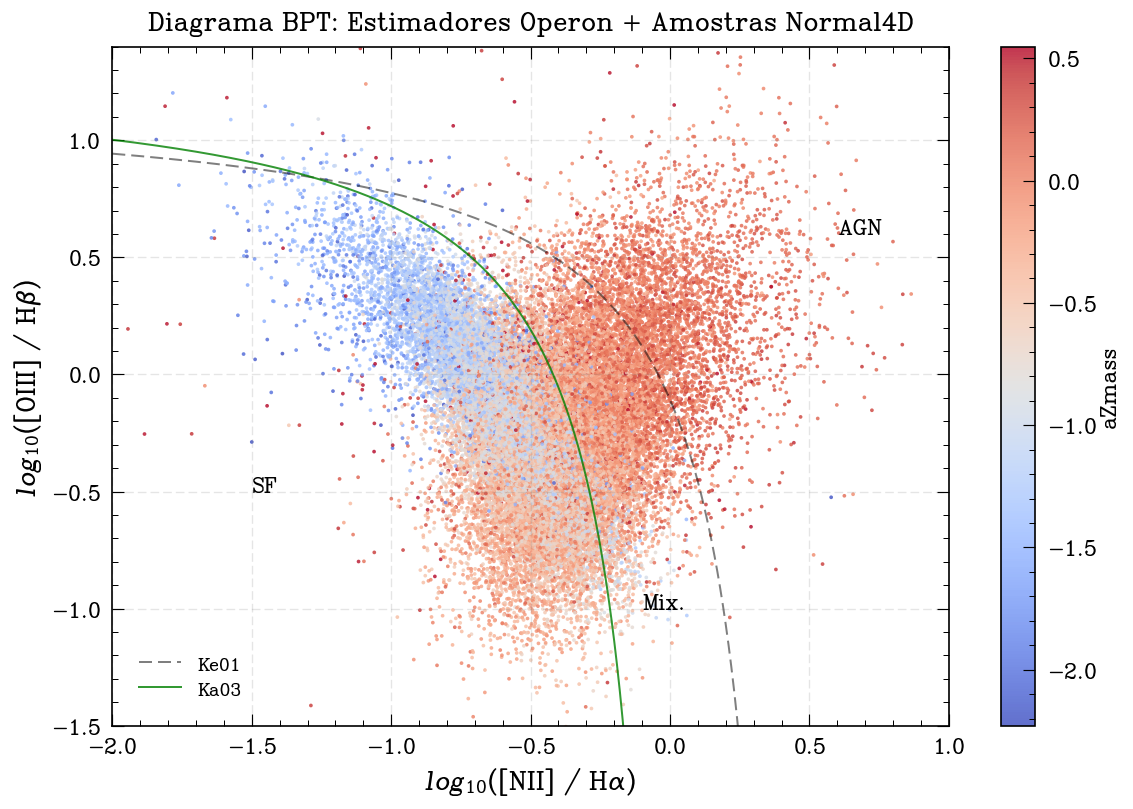

In [33]:
# Plotar amostras geradas coloridas por alguma feature
p.show_bpt(df_amostras, col_x, title="Estimadores Operon + Amostras Normal4D")

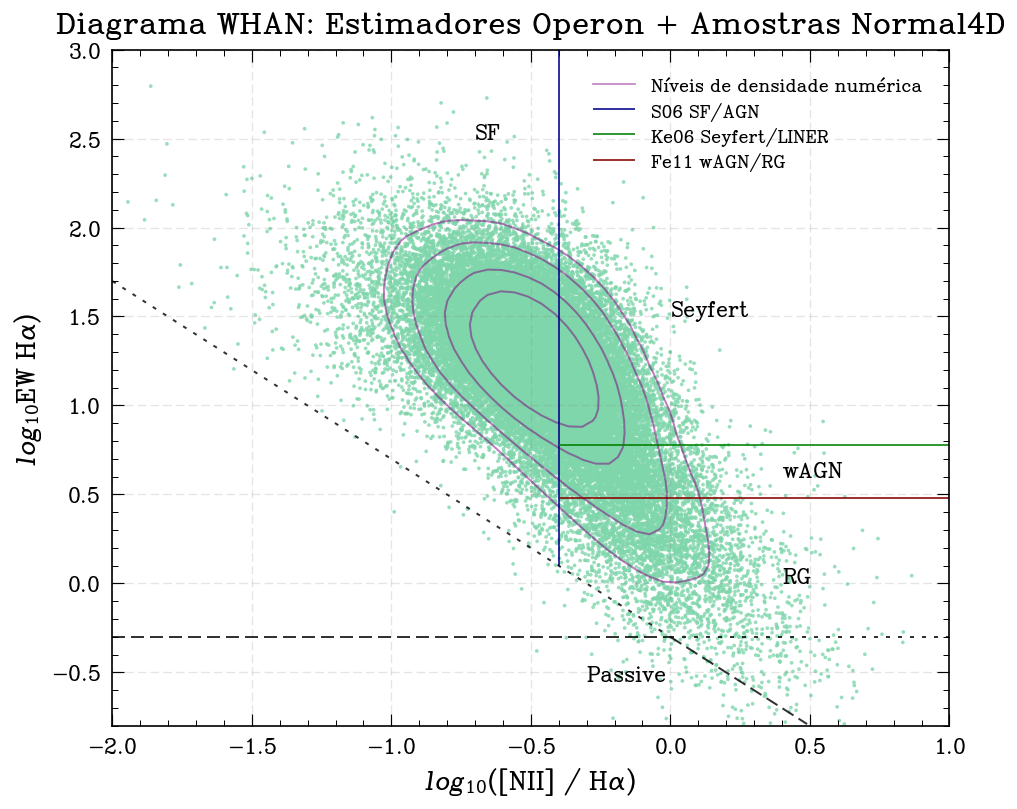

In [34]:
# Plotar com curvas de densidade
p.show_whan(df_amostras, title="Estimadores Operon + Amostras Normal4D", densities=True)

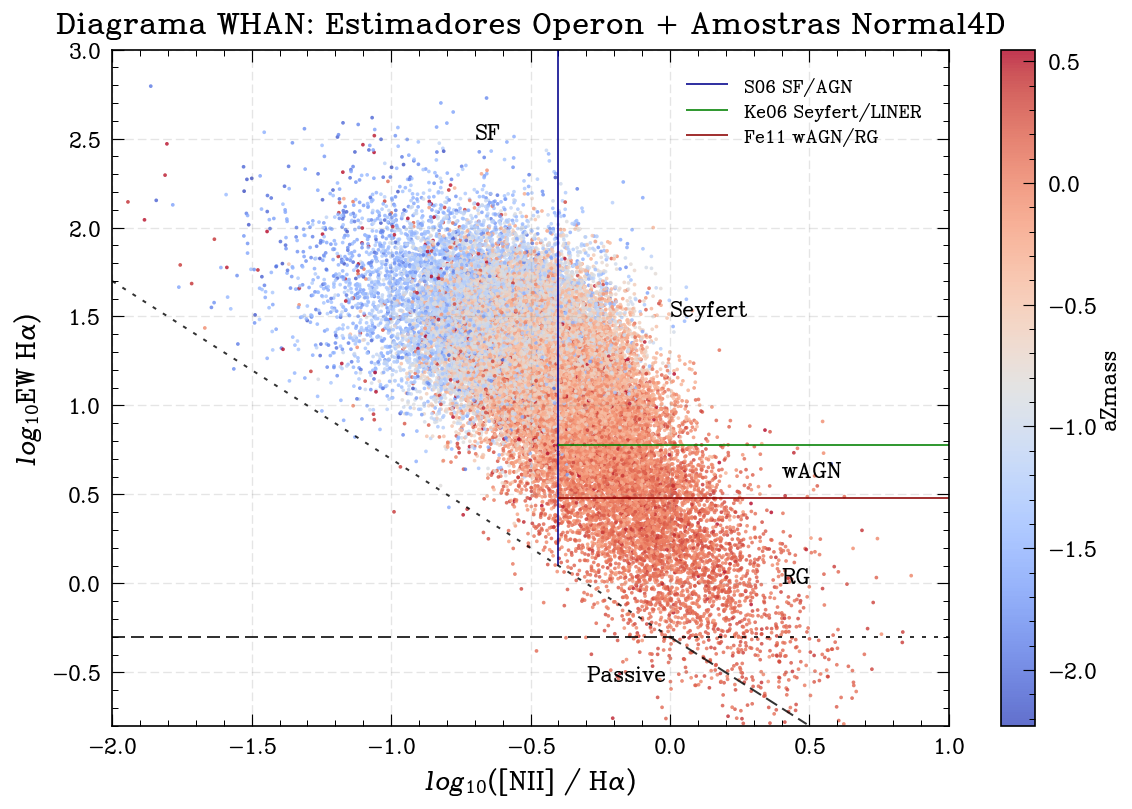

In [35]:
p.show_whan(df_amostras, col_x, title="Estimadores Operon + Amostras Normal4D")